# Parte 1: Análisis Exploratorio de Datos (EDA)

El objetivo de este notebook es conectarse a **Snowflake**, extraer un subset manejable mediante *pushdown computation* desde la vista `analytics.train_set`, y entender la distribución de los datos antes de modelar.

## Objetivos
1. Validar la conexión a Snowflake usando variables de entorno.
2. Entender el comportamiento del *Target* (`total_amount`).
3. Investigar la correlación entre variables independientes y descubrir posibles casos de *Data Leakage*.
4. Analizar la cardinalidad y distribución estadística (boxplots, histogramas).

> ⚠️ **Regla de oro**: En ningún momento cargamos los ~20 GB completos. Usamos `SAMPLE` de Snowflake para traer una muestra representativa.

---
## 0. Configuración e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import sys
import os

# Agregar raíz del proyecto al path para importar src/
sys.path.insert(0, os.path.abspath('..'))

from dotenv import load_dotenv
load_dotenv('../.env')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


---
## 1. Conexión a Snowflake y Extracción de Muestra

Usamos la función `fetch_sample` de `src/data/ingestion.py`. El parámetro `sample_prob` indica qué porcentaje de filas se extrae con `TABLESAMPLE` de Snowflake (corre del lado del servidor, sin descargar los 20 GB).

In [2]:
from src.data.ingestion import fetch_sample

# Extraemos ~1% del train_set para el EDA (aprox. 1-3 millones de filas)
# Ajusta sample_prob si tu máquina tiene más o menos RAM
SAMPLE_PROB = 1.0  # 1% del dataset de entrenamiento

query = "SELECT * FROM ANALYTICS.TRAIN_SET"

print(f'Extrayendo muestra ({SAMPLE_PROB}%) de ANALYTICS.TRAIN_SET...')
df = fetch_sample(query, sample_prob=SAMPLE_PROB)

print(f'✅ Muestra cargada: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

Extrayendo muestra (1.0%) de ANALYTICS.TRAIN_SET...
✅ Muestra cargada: 7,778,277 filas × 39 columnas


,pickup_datetime,dropoff_datetime,pu_location_id,do_location_id,vendor_name,rate_code_id,rate_code_desc,payment_type_desc,passenger_count,trip_distance,...,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,source_service,trip_duration_min,avg_speed_mph,tip_pct
0,2015-07-04 10:09:22,2015-07-04 10:22:13,148,68,VeriFone Inc.,1.0,Standard rate,Credit card,2.0,3.39,...,10,2015-07-04,10,6,7,2015,yellow,13,15.65,21.28
1,2015-07-30 00:06:22,2015-07-30 00:18:59,161,234,Creative Mobile Technologies,1.0,Standard rate,Credit card,1.0,2.50,...,0,2015-07-30,0,4,7,2015,yellow,12,12.50,28.10
2,2015-07-30 00:03:07,2015-07-30 00:06:52,114,113,Creative Mobile Technologies,1.0,Standard rate,Credit card,1.0,0.80,...,0,2015-07-30,0,4,7,2015,yellow,3,16.00,20.00


### 1.1 Vista general del esquema

In [3]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes.to_string())
print(f'\nMemoria usada: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

=== TIPOS DE DATOS ===
pickup_datetime          datetime64[us]
dropoff_datetime         datetime64[us]
pu_location_id                      str
do_location_id                      str
vendor_name                         str
rate_code_id                    float64
rate_code_desc                      str
payment_type_desc                   str
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
run_id                              str
ingested_at_utc          datetime64[us]
source_year                       int64
source_month                      int64
service_type                        str
pu_zone          

In [4]:
print('=== VALORES NULOS (%) ===')
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].to_string())
if null_pct.max() == 0:
    print('Sin valores nulos en la muestra.')

=== VALORES NULOS (%) ===
airport_fee              95.635872
congestion_surcharge     72.227654
avg_speed_mph             1.119464
passenger_count           0.943474
rate_code_id              0.943474
tip_pct                   0.230064
improvement_surcharge     0.000013


In [5]:
print('=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===')
df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

=== ESTADÍSTICAS DESCRIPTIVAS (numéricas) ===


,count,mean,min,1%,5%,25%,50%,75%,95%,99%,max,std
pickup_datetime,7778277,2018-01-28 18:43:57.016852,2015-01-01 00:00:00,2015-01-17 18:15:08.360000,2015-03-23 09:56:42.400000,2016-03-10 14:08:04,2017-08-07 09:08:48,2019-05-06 12:52:12,2023-01-02 18:52:59.600000,2023-10-23 22:13:49.680000,2023-12-31 23:58:37,NaN
dropoff_datetime,7778277,2018-01-28 19:00:55.800934,2015-01-01 00:00:00,2015-01-17 18:26:57.840000,2015-03-23 10:12:13,2016-03-10 14:24:54,2017-08-07 09:27:40,2019-05-06 13:09:43,2023-01-02 19:05:20,2023-10-23 22:25:42.920000,2024-01-01 00:30:09,NaN
rate_code_id,7704891.0,1.101232,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,99.0,2.217585
passenger_count,7704891.0,1.571445,0.0,1.0,1.0,1.0,1.0,2.0,5.0,6.0,9.0,1.219778
trip_distance,7778277.0,5.319195,-16183.31,0.03,0.5,1.0,1.7,3.2,10.92,19.0,8000003.3,2959.0289
fare_amount,7778277.0,13.499684,-445.55,3.0,4.5,6.5,9.5,15.37,38.0,55.0,325478.15,117.960866
extra,7778277.0,0.562609,-7.5,0.0,0.0,0.0,0.5,0.5,2.5,3.5,94.8,0.906046
mta_tax,7778277.0,0.494202,-0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,33.65,0.064105
tip_amount,7778277.0,1.948165,-200.0,0.0,0.0,0.0,1.46,2.65,6.66,12.37,600.0,2.797236
tolls_amount,7778277.0,0.341214,-40.3,0.0,0.0,0.0,0.0,0.0,5.54,6.55,957.6,1.741524


**📝 Conclusión 1.1:** Revisamos los tipos de datos, nulos y estadísticas básicas. En este punto podemos identificar rápidamente columnas con nulos altos que requerirán imputación o eliminación, y variables numéricas con rangos sospechosos (valores negativos, ceros imposibles, máximos extremos).

---
## 2. Análisis Univariado del Target (`total_amount`)

Entender la variable que queremos predecir es el primer paso. Buscamos: distribución, asimetría (skewness), valores imposibles (negativos, cero) y la presencia de outliers extremos.

In [6]:
target = 'total_amount'

print(f'=== ESTADÍSTICAS DEL TARGET: {target} ===')
print(f'  Media:    ${df[target].mean():.2f}')
print(f'  Mediana:  ${df[target].median():.2f}')
print(f'  Std:      ${df[target].std():.2f}')
print(f'  Skewness: {df[target].skew():.3f}')
print(f'  Kurtosis: {df[target].kurtosis():.3f}')
print(f'  Min:      ${df[target].min():.2f}')
print(f'  Max:      ${df[target].max():.2f}')
print(f'  Negativos o cero: {(df[target] <= 0).sum():,} ({(df[target] <= 0).mean()*100:.2f}%)')

=== ESTADÍSTICAS DEL TARGET: total_amount ===
  Media:    $17.62
  Mediana:  $12.96
  Std:      $118.31
  Skewness: 2678.965
  Kurtosis: 7363411.262
  Min:      $-445.85
  Max:      $325478.98
  Negativos o cero: 16,454 (0.21%)


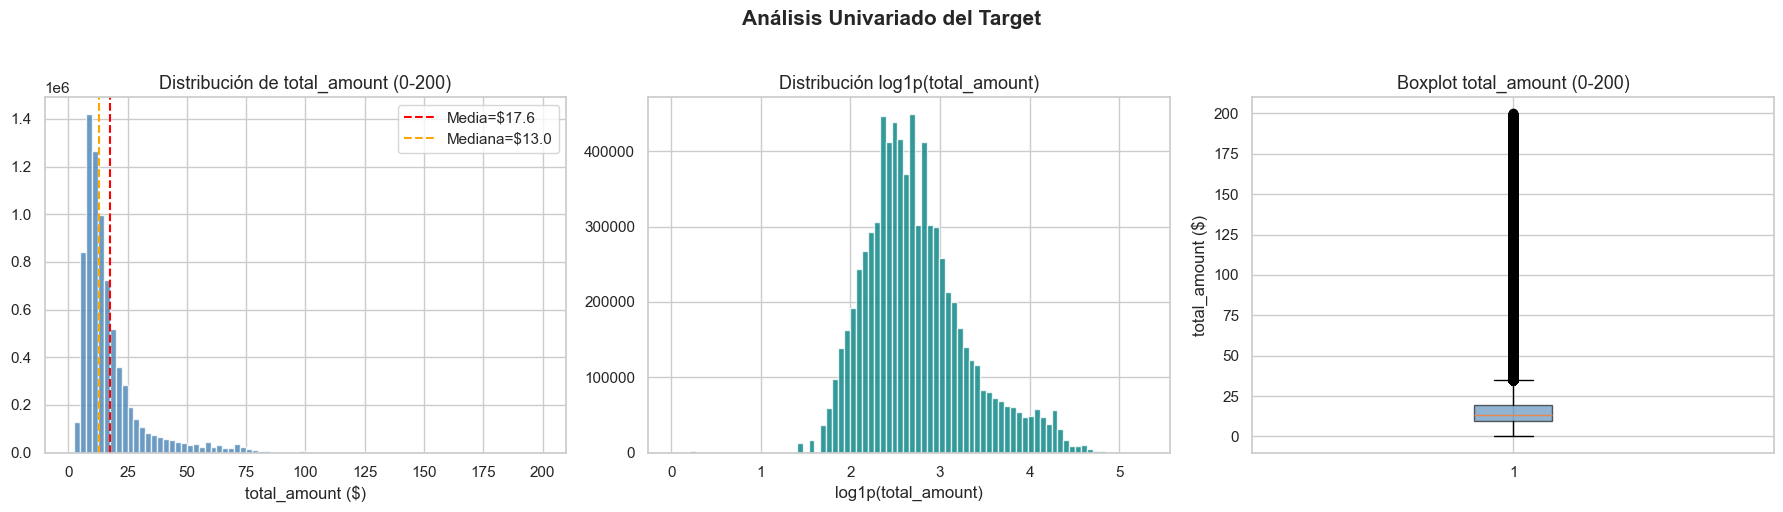

Gráfica guardada en data/interim/


In [7]:
# Filtrar rango razonable para visualizar (excluimos extremos para la gráfica)
df_plot = df[(df[target] > 0) & (df[target] < 200)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma original
axes[0].hist(df_plot[target], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_plot[target].mean(), color='red', linestyle='--', label=f'Media=${df_plot[target].mean():.1f}')
axes[0].axvline(df_plot[target].median(), color='orange', linestyle='--', label=f'Mediana=${df_plot[target].median():.1f}')
axes[0].set_title('Distribución de total_amount (0-200)', fontsize=13)
axes[0].set_xlabel('total_amount ($)')
axes[0].legend()

# Log-transformado
log_target = np.log1p(df_plot[target])
axes[1].hist(log_target, bins=80, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución log1p(total_amount)', fontsize=13)
axes[1].set_xlabel('log1p(total_amount)')

# Boxplot
axes[2].boxplot(df_plot[target], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].set_title('Boxplot total_amount (0-200)', fontsize=13)
axes[2].set_ylabel('total_amount ($)')

plt.suptitle('Análisis Univariado del Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/interim/01_target_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfica guardada en data/interim/')

In [8]:
# Análisis de outliers por IQR
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df[target] < lower_fence) | (df[target] > upper_fence)]
print(f'Rango IQR válido: [{lower_fence:.2f}, {upper_fence:.2f}]')
print(f'Outliers por IQR: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)')
print(f'\nUmbral de negocio sugerido: $2.50 (mínimo tarifa NYC) a $500')

Rango IQR válido: [-6.09, 34.95]
Outliers por IQR: 714,742 (9.19%)

Umbral de negocio sugerido: $2.50 (mínimo tarifa NYC) a $500


**📝 Conclusión 2:** El target `total_amount` presenta **asimetría positiva (right-skewed)** — hay muchos viajes baratos y una cola larga de viajes costosos. 
- Valores negativos o cero son **errores de registro** (cancelaciones, disputas) → se filtran.
- La transformación `log1p` normaliza la distribución, útil para algunos modelos lineales.
- Los boosting trees (XGBoost, LightGBM, CatBoost) manejan la asimetría nativamente sin necesitar la transformación.
- Se usará un umbral de negocio: `total_amount > 2.50` y `total_amount < 500`.

---
## 3. Análisis Bivariado: Features vs Target

### 3.1 Correlación numérica con el target

In [9]:
# Columnas numéricas disponibles
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Columnas numéricas ({len(numeric_cols)}): {numeric_cols}')

Columnas numéricas (22): ['rate_code_id', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'source_year', 'source_month', 'pickup_hour', 'dropoff_hour', 'day_of_week', 'month', 'year', 'trip_duration_min', 'avg_speed_mph', 'tip_pct']


In [10]:
# Matriz de correlación de Pearson
corr_matrix = df[numeric_cols].corr()

# Mostrar correlación con el target ordenada
target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)
print('=== CORRELACIÓN CON total_amount (Pearson) ===')
print(target_corr.to_string())

=== CORRELACIÓN CON total_amount (Pearson) ===
fare_amount              0.999286
airport_fee              0.613673
tip_amount               0.086102
tolls_amount             0.077183
avg_speed_mph            0.041492
year                     0.021583
source_year              0.021583
extra                    0.021539
improvement_surcharge    0.014698
rate_code_id             0.012371
trip_duration_min        0.012058
source_month             0.004612
month                    0.004612
trip_distance            0.004327
dropoff_hour             0.001798
tip_pct                  0.001560
pickup_hour              0.001426
passenger_count          0.000214
day_of_week             -0.001503
mta_tax                 -0.012768
congestion_surcharge    -0.060932


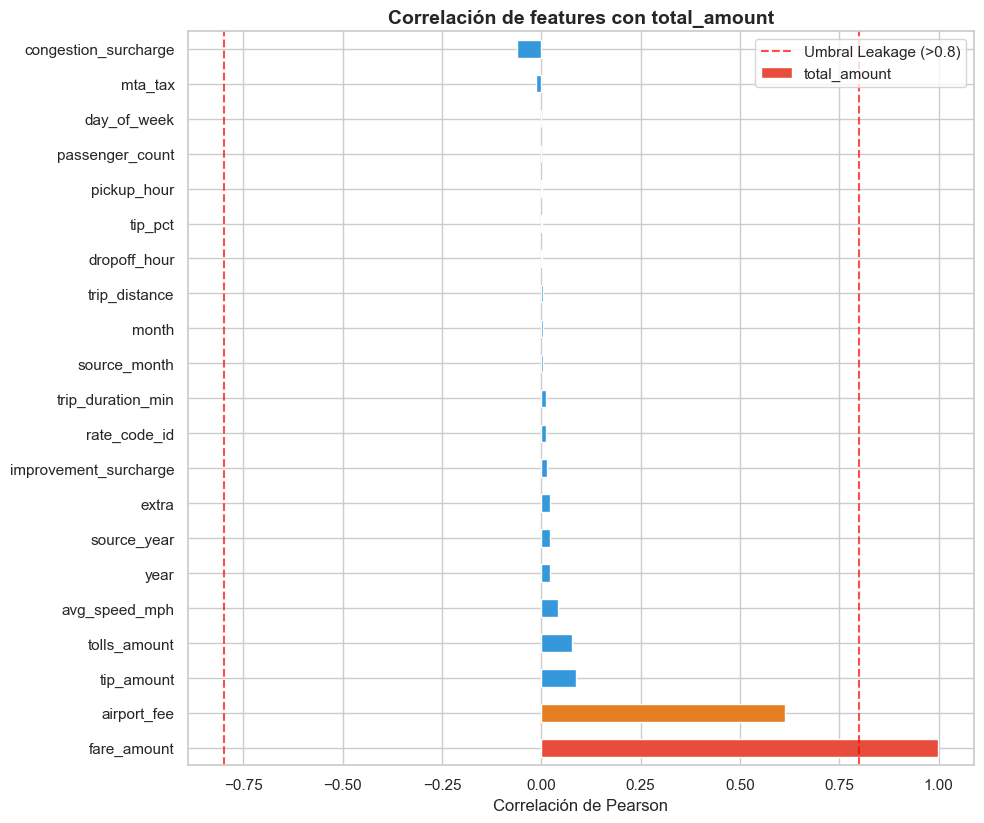

In [11]:
fig, ax = plt.subplots(figsize=(10, max(6, len(target_corr) * 0.4)))
colors = ['#e74c3c' if v > 0.8 else '#e67e22' if v > 0.5 else '#3498db' 
          for v in target_corr.abs()]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.8, color='red', linestyle='--', alpha=0.7, label='Umbral Leakage (>0.8)')
ax.axvline(-0.8, color='red', linestyle='--', alpha=0.7)
ax.set_title('Correlación de features con total_amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.legend()
plt.tight_layout()
plt.savefig('../data/interim/01_correlations.png', bbox_inches='tight', dpi=120)
plt.show()

### 3.2 Identificación de Data Leakage

**Data Leakage** ocurre cuando incluimos variables que solo se conocen *después* de que el viaje finaliza. En un modelo de predicción de precio, el modelo debe funcionar con información disponible **al inicio del viaje**.

In [12]:
# Columnas que constituyen Data Leakage: son componentes del target
# o se conocen solo al FINALIZAR el viaje

LEAKAGE_COLUMNS = [
    # Componentes directos del total_amount (leakage matemático)
    'fare_amount',          # total_amount = fare_amount + extras
    'extra',                # recargos conocidos al cierre
    'mta_tax',              # tax calculado al cierre
    'tip_amount',           # propina: se da al finalizar
    'tolls_amount',         # peajes: se saben al terminar la ruta
    'improvement_surchARGE', # cargo fijo al cierre
    'congestion_surcharge', # calculado al finalizar
    'airport_fee',          # aplica solo en destinos específicos
    'tip_pct',              # derivada de tip_amount/fare_amount
    
    # Información de cierre del viaje
    'dropoff_datetime',     # solo se sabe cuando termina el viaje
    'dropoff_date',
    'dropoff_hour',
    'trip_duration_min',    # se calcula con dropoff_datetime
    'avg_speed_mph',        # requiere trip_duration_min
    
    # IDs internos de trazabilidad (no predictivos)
    'run_id',
    'ingested_at_utc',
]

# Verificar cuáles existen en el dataframe
leakage_present = [c for c in LEAKAGE_COLUMNS if c in df.columns]
print(f'Columnas de leakage presentes en el dataset: {len(leakage_present)}')
for col in leakage_present:
    corr_val = df[[col, target]].corr().iloc[0, 1] if col in numeric_cols else 'N/A (categórica)'
    print(f'  ✗ {col:<30} corr={corr_val if isinstance(corr_val, str) else f"{corr_val:.3f}"}')

Columnas de leakage presentes en el dataset: 15
  ✗ fare_amount                    corr=0.999
  ✗ extra                          corr=0.022
  ✗ mta_tax                        corr=-0.013
  ✗ tip_amount                     corr=0.086
  ✗ tolls_amount                   corr=0.077
  ✗ congestion_surcharge           corr=-0.061
  ✗ airport_fee                    corr=0.614
  ✗ tip_pct                        corr=0.002
  ✗ dropoff_datetime               corr=N/A (categórica)
  ✗ dropoff_date                   corr=N/A (categórica)
  ✗ dropoff_hour                   corr=0.002
  ✗ trip_duration_min              corr=0.012
  ✗ avg_speed_mph                  corr=0.041
  ✗ run_id                         corr=N/A (categórica)
  ✗ ingested_at_utc                corr=N/A (categórica)


In [13]:
# Columnas SEGURAS (disponibles al inicio del viaje)
SAFE_COLUMNS = [
    # Características del viaje al inicio
    'passenger_count',
    'trip_distance',
    'rate_code_id',
    'rate_code_desc',
    'payment_type_desc',
    'vendor_name',
    
    # Temporales del pickup
    'pickup_datetime',
    'pickup_date',
    'pickup_hour',
    'day_of_week',
    'month',
    'year',
    
    # Geográficas del origen/destino
    'pu_location_id',
    'do_location_id',
    'pu_zone',
    'pu_borough',
    'do_zone',
    'do_borough',
    
    # Metadatos de servicio
    'source_service',
    'service_type',
]

safe_present = [c for c in SAFE_COLUMNS if c in df.columns]
print(f'Columnas seguras para modelado: {len(safe_present)}')
print(safe_present)

Columnas seguras para modelado: 20
['passenger_count', 'trip_distance', 'rate_code_id', 'rate_code_desc', 'payment_type_desc', 'vendor_name', 'pickup_datetime', 'pickup_date', 'pickup_hour', 'day_of_week', 'month', 'year', 'pu_location_id', 'do_location_id', 'pu_zone', 'pu_borough', 'do_zone', 'do_borough', 'source_service', 'service_type']


### 3.3 Análisis temporal: Total por hora del día

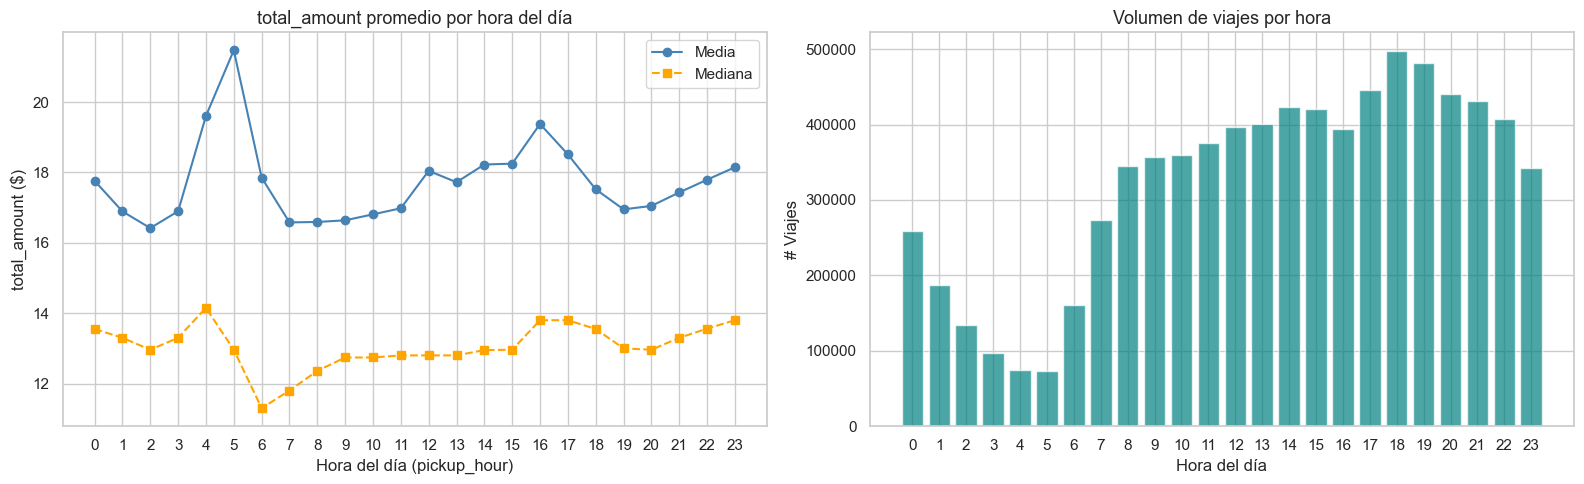

In [14]:
if 'pickup_hour' in df.columns:
    hourly = df.groupby('pickup_hour')[target].agg(['mean', 'median', 'count'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].plot(hourly.index, hourly['mean'], marker='o', color='steelblue', label='Media')
    axes[0].plot(hourly.index, hourly['median'], marker='s', color='orange', linestyle='--', label='Mediana')
    axes[0].set_title('total_amount promedio por hora del día', fontsize=13)
    axes[0].set_xlabel('Hora del día (pickup_hour)')
    axes[0].set_ylabel('total_amount ($)')
    axes[0].legend()
    axes[0].set_xticks(range(0, 24))
    
    axes[1].bar(hourly.index, hourly['count'], color='teal', alpha=0.7)
    axes[1].set_title('Volumen de viajes por hora', fontsize=13)
    axes[1].set_xlabel('Hora del día')
    axes[1].set_ylabel('# Viajes')
    axes[1].set_xticks(range(0, 24))
    
    plt.tight_layout()
    plt.savefig('../data/interim/01_hourly_analysis.png', bbox_inches='tight', dpi=120)
    plt.show()

### 3.4 Análisis por día de la semana

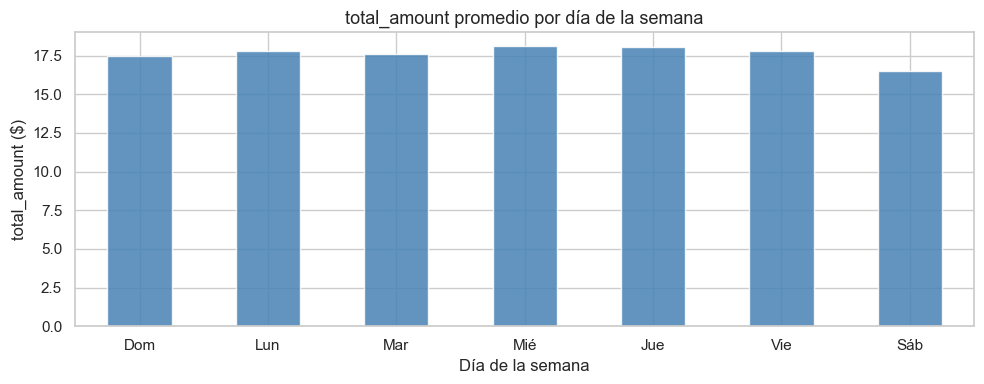

In [15]:
if 'day_of_week' in df.columns:
    day_names = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}
    daily = df.groupby('day_of_week')[target].mean().rename(index=day_names)

    fig, ax = plt.subplots(figsize=(10, 4))
    daily.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title('total_amount promedio por día de la semana', fontsize=13)
    ax.set_xlabel('Día de la semana')
    ax.set_ylabel('total_amount ($)')
    ax.set_xticklabels(daily.index, rotation=0)
    plt.tight_layout()
    plt.savefig('../data/interim/01_daily_analysis.png', bbox_inches='tight', dpi=120)
    plt.show()

### 3.5 Trip distance vs total_amount

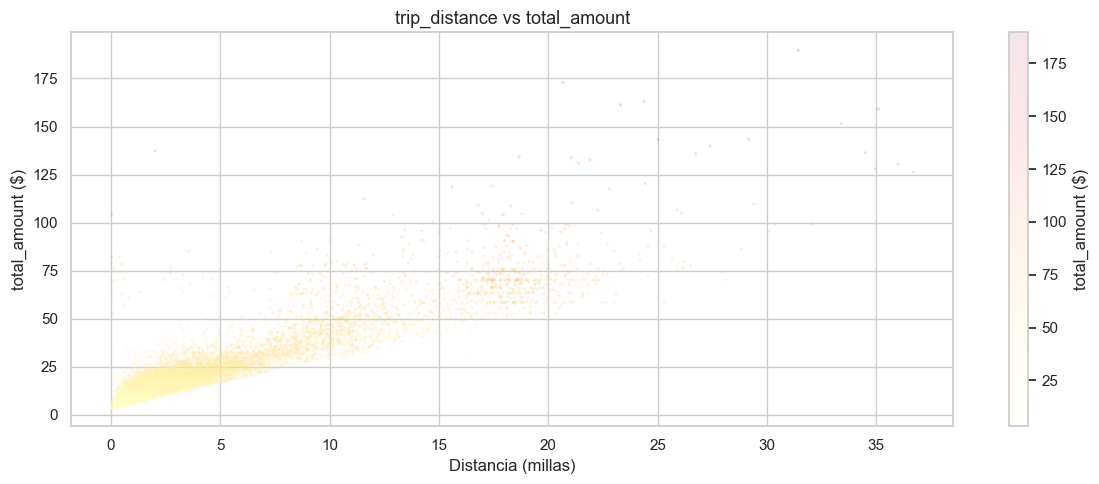

Correlación trip_distance ↔ total_amount: 0.913


In [16]:
if 'trip_distance' in df.columns:
    # Filtrar para la visualización
    df_scatter = df[
        (df['trip_distance'] > 0) & (df['trip_distance'] < 50) &
        (df[target] > 2.5) & (df[target] < 200)
    ].sample(min(20000, len(df)), random_state=RANDOM_STATE)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    scatter = ax.scatter(
        df_scatter['trip_distance'], df_scatter[target],
        alpha=0.1, s=2, c=df_scatter[target], cmap='YlOrRd'
    )
    plt.colorbar(scatter, ax=ax, label='total_amount ($)')
    ax.set_title('trip_distance vs total_amount', fontsize=13)
    ax.set_xlabel('Distancia (millas)')
    ax.set_ylabel('total_amount ($)')
    plt.tight_layout()
    plt.savefig('../data/interim/01_distance_vs_amount.png', bbox_inches='tight', dpi=120)
    plt.show()
    
    corr = df_scatter[['trip_distance', target]].corr().iloc[0, 1]
    print(f'Correlación trip_distance ↔ total_amount: {corr:.3f}')

### 3.6 Análisis de variables categóricas

In [17]:
cat_cols = ['pu_borough', 'do_borough', 'payment_type_desc', 'rate_code_desc', 'vendor_name', 'source_service']
cat_cols_present = [c for c in cat_cols if c in df.columns]

for col in cat_cols_present:
    print(f'\n{col}: {df[col].nunique()} valores únicos')
    print(df[col].value_counts().head(10).to_string())


pu_borough: 8 valores únicos
pu_borough
Manhattan        6643412
Queens            648818
Brooklyn          333391
Unknown            96261
Bronx              48504
NaN                 6819
EWR                  632
Staten Island        440

do_borough: 8 valores únicos
do_borough
Manhattan        6486579
Queens            549168
Brooklyn          521538
Bronx              95963
Unknown            88466
NaN                20434
EWR                13992
Staten Island       2137

payment_type_desc: 6 valores únicos
payment_type_desc
Credit card    5183284
Cash           2465134
Other            73386
No charge        36522
Dispute          19924
Unknown             27

rate_code_desc: 7 valores únicos
rate_code_desc
Standard rate            7460856
JFK                       174126
Unknown                    77234
Negotiated fare            45511
Newark                     15084
Nassau or Westchester       5395
Group ride                    71

vendor_name: 3 valores únicos
vendor_name
Ve

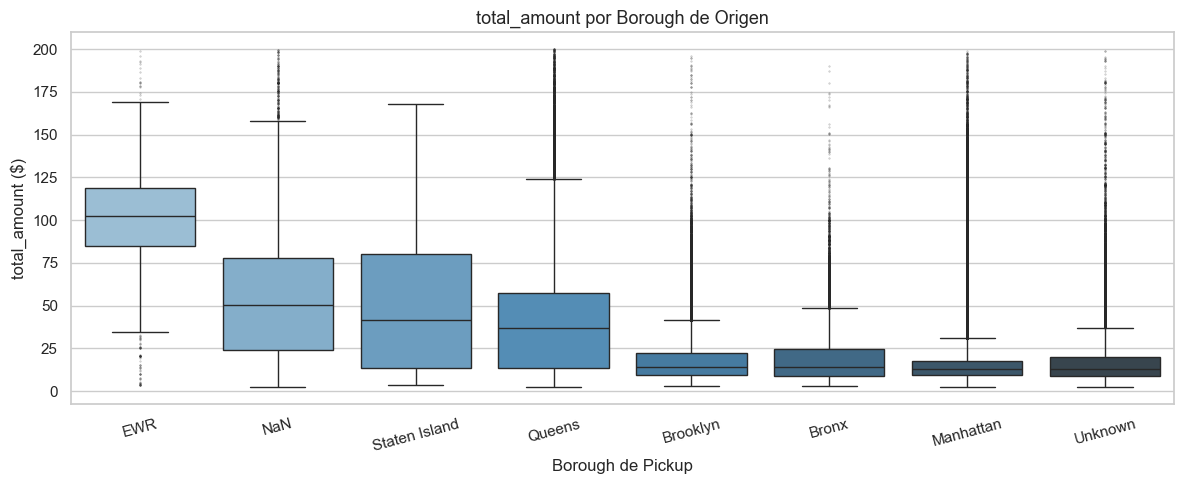

In [18]:
# Boxplots de total_amount por borough de origen
if 'pu_borough' in df.columns:
    df_box = df[(df[target] > 2.5) & (df[target] < 200) & df['pu_borough'].notna()]
    order = df_box.groupby('pu_borough')[target].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data=df_box, x='pu_borough', y=target, order=order,
        palette='Blues_d', flierprops=dict(marker='.', markersize=1, alpha=0.3), ax=ax
    )
    ax.set_title('total_amount por Borough de Origen', fontsize=13)
    ax.set_xlabel('Borough de Pickup')
    ax.set_ylabel('total_amount ($)')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('../data/interim/01_borough_boxplot.png', bbox_inches='tight', dpi=120)
    plt.show()

---
## 4. Heatmap de Correlaciones (features seguras)

Solo con variables sin leakage para tener la imagen limpia que guiará el feature engineering.

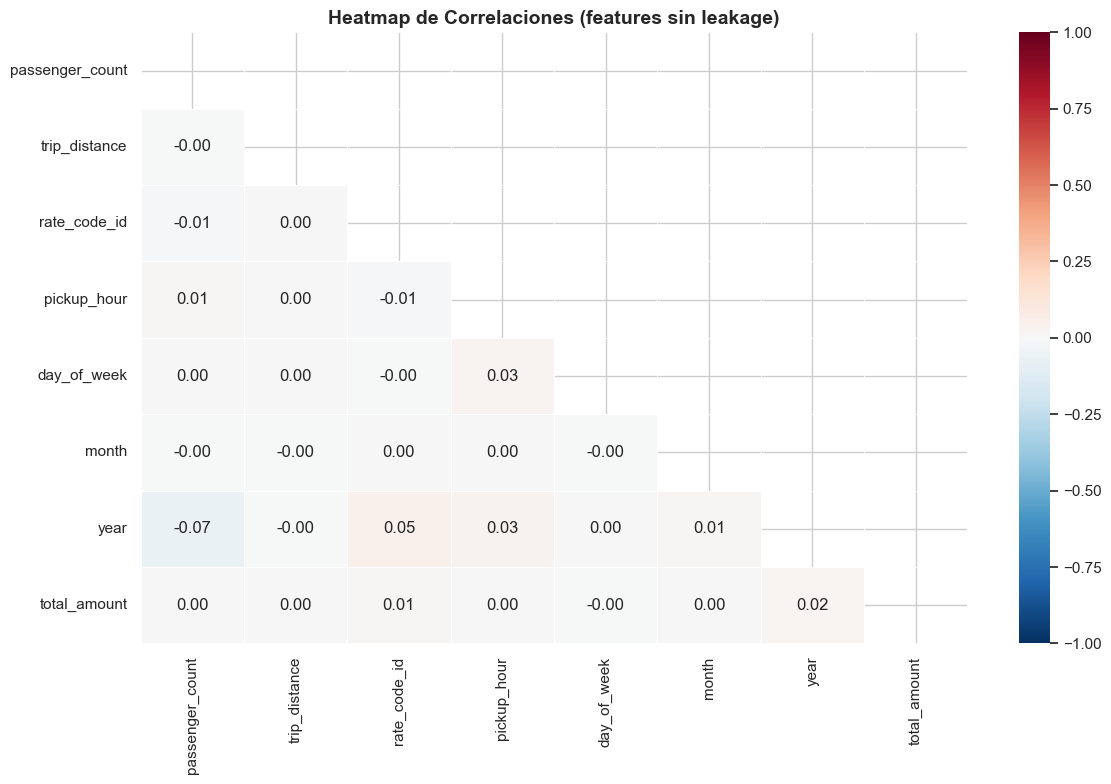

In [19]:
numeric_safe = [c for c in safe_present if c in numeric_cols] + [target]
numeric_safe = [c for c in numeric_safe if c in df.columns]

corr_safe = df[numeric_safe].corr()

mask = np.triu(np.ones_like(corr_safe, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_safe, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Heatmap de Correlaciones (features sin leakage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/interim/01_correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 5. Análisis de Outliers por Regla de Negocio

Más allá del IQR matemático, aplicamos lógica del dominio NYC Taxi.

In [20]:
print('=== REGLAS LÓGICAS DE NEGOCIO ===')

rules = {
    'total_amount <= 0': (df['total_amount'] <= 0).sum(),
    'total_amount > 500': (df['total_amount'] > 500).sum(),
    'trip_distance <= 0': (df['trip_distance'] <= 0).sum() if 'trip_distance' in df.columns else 'N/A',
    'trip_distance > 200': (df['trip_distance'] > 200).sum() if 'trip_distance' in df.columns else 'N/A',
    'passenger_count <= 0': (df['passenger_count'] <= 0).sum() if 'passenger_count' in df.columns else 'N/A',
    'passenger_count > 6': (df['passenger_count'] > 6).sum() if 'passenger_count' in df.columns else 'N/A',
    'PICKUP_HOUR is null': df['pickup_hour'].isnull().sum() if 'pickup_hour' in df.columns else 'N/A',
}

for rule, count in rules.items():
    pct = f'({count/len(df)*100:.3f}%)' if isinstance(count, (int, np.integer)) else ''
    print(f'  {rule:<35}: {str(count):>8} {pct}')

print(f'\nTotal de filas en la muestra: {len(df):,}')

=== REGLAS LÓGICAS DE NEGOCIO ===
  total_amount <= 0                  :    16454 (0.212%)
  total_amount > 500                 :       54 (0.001%)
  trip_distance <= 0                 :    70231 (0.903%)
  trip_distance > 200                :      120 (0.002%)
  passenger_count <= 0               :    52592 (0.676%)
  passenger_count > 6                :       74 (0.001%)
  PICKUP_HOUR is null                :        0 (0.000%)

Total de filas en la muestra: 7,778,277


---
## 6. Distribución Temporal (años en el dataset)

In [ ]:
if 'year' in df.columns:
    yearly = df.groupby('year').agg(
        count=('total_amount', 'count'),
        avg_amount=('total_amount', 'mean')
    ).reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].bar(yearly['year'], yearly['count'], color='steelblue', alpha=0.8)
    axes[0].set_title('Viajes por año', fontsize=13)
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('# Viajes en la muestra')
    
    axes[1].plot(yearly['year'], yearly['avg_amount'], marker='o', color='orange')
    axes[1].set_title('total_amount promedio por año', fontsize=13)
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('$ promedio')
    
    plt.tight_layout()
    plt.savefig('../data/interim/01_yearly_trends.png', bbox_inches='tight', dpi=120)
    plt.show()

---
## 7. Resumen de Hallazgos y Plan de Acción

Esta celda consolida las conclusiones del EDA para guiar el notebook 02 (limpieza).

In [22]:
print('=' * 60)
print('HALLAZGOS DEL EDA - RESUMEN EJECUTIVO')
print('=' * 60)

print("""
1. TARGET (total_amount)
   - Distribución right-skewed (cola hacia valores altos)
   - Valores negativos/cero presentes → error de registro → FILTRAR
   - Umbral de negocio: $2.50 < total_amount < $500
   - Los modelos de boosting manejan skewness sin transformación

2. DATA LEAKAGE DETECTADO
   - fare_amount, tip_amount, tolls_amount, extra, mta_tax,
     improvement_surcharge, congestion_surcharge, airport_fee → ELIMINAR
   - tip_pct (derivada de tip_amount) → ELIMINAR
   - dropoff_datetime, trip_duration_min, avg_speed_mph → ELIMINAR
   - run_id, ingested_at_utc → no predictivos → ELIMINAR

3. OUTLIERS A FILTRAR
   - trip_distance <= 0 o > 200 millas → imposibles
   - passenger_count <= 0 o > 6 → fuera del rango de una taxi

4. VARIABLES MÁS PREDICTIVAS (sin leakage)
   - trip_distance (correlación directa con precio)
   - pickup_hour, day_of_week (patrones tarifarios)
   - pu_borough, do_borough (zonas geográficas)
   - rate_code_desc (diferencia tarifas JFK, Newark, etc.)

5. ACCIONES PARA EL NOTEBOOK 02
   - Eliminar columnas de leakage
   - Filtrar outliers de negocio
   - Imputar/manejar nulos en passenger_count, rate_code_id
   - Agrupar zonas de baja frecuencia en 'Other'
""")

# Exportar lista de columnas útiles para el siguiente notebook
eda_results = {
    'leakage_cols': LEAKAGE_COLUMNS,
    'safe_cols': safe_present,
    'target': target,
    'amount_min': 2.50,
    'amount_max': 500.0,
}
import json
os.makedirs('../data/interim', exist_ok=True)
with open('../data/interim/eda_config.json', 'w') as f:
    json.dump(eda_results, f, indent=2)
    
print('\n✅ Configuración de EDA exportada a data/interim/eda_config.json')
print('   → Este archivo guía el notebook 02 de limpieza.')

HALLAZGOS DEL EDA - RESUMEN EJECUTIVO

1. TARGET (total_amount)
   - Distribución right-skewed (cola hacia valores altos)
   - Valores negativos/cero presentes → error de registro → FILTRAR
   - Umbral de negocio: $2.50 < total_amount < $500
   - Los modelos de boosting manejan skewness sin transformación

2. DATA LEAKAGE DETECTADO
   - fare_amount, tip_amount, tolls_amount, extra, mta_tax,
     improvement_surcharge, congestion_surcharge, airport_fee → ELIMINAR
   - tip_pct (derivada de tip_amount) → ELIMINAR
   - dropoff_datetime, trip_duration_min, avg_speed_mph → ELIMINAR
   - run_id, ingested_at_utc → no predictivos → ELIMINAR

3. OUTLIERS A FILTRAR
   - trip_distance <= 0 o > 200 millas → imposibles
   - passenger_count <= 0 o > 6 → fuera del rango de una taxi

4. VARIABLES MÁS PREDICTIVAS (sin leakage)
   - trip_distance (correlación directa con precio)
   - pickup_hour, day_of_week (patrones tarifarios)
   - pu_borough, do_borough (zonas geográficas)
   - rate_code_desc (difere